In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine


In [2]:
data=load_wine(as_frame=True)

In [3]:
df=data.frame

In [4]:
df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


In [5]:
X=df.drop("target",axis=1)

In [6]:
y=df["target"]

In [7]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_scaled=sc.fit_transform(X)

In [8]:
target_names=data.target_names

In [9]:
def plot_2d(Z, y, title):
    plt.figure(figsize=(6, 5))
    for label in np.unique(y):
        plt.scatter(
            Z[y == label, 0],
            Z[y == label, 1],
            label=target_names[label],
            s=45
        )
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.title(title)
    plt.legend()
    plt.show()

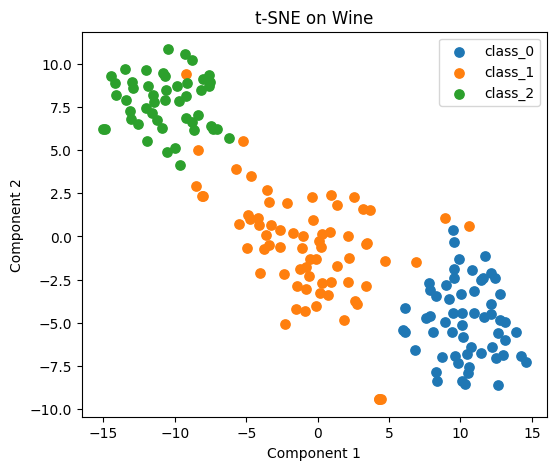

In [10]:
from sklearn.manifold import TSNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    max_iter=1000,
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)
plot_2d(X_tsne, y, "t-SNE on Wine")

In [11]:
tsne.kl_divergence_

0.3762654662132263

In [13]:
tsne.learning_rate_

np.float64(50.0)

In [14]:
tsne.n_iter_

849

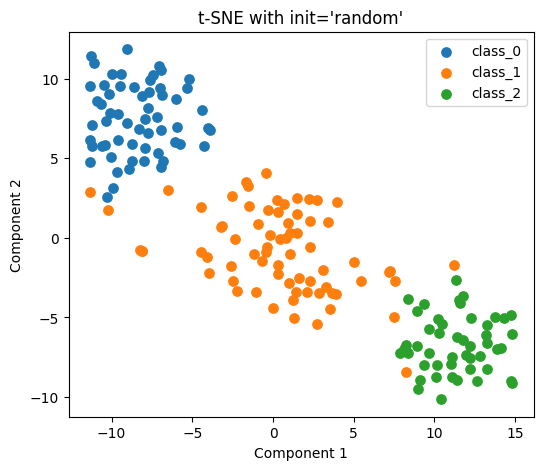

In [15]:
tsne_random = TSNE(
    n_components=2,
    init="random",
    perplexity=30,
    learning_rate="auto",
    max_iter=1000,
    random_state=42
)
Z_random = tsne_random.fit_transform(X_scaled)

plot_2d(Z_random, y, "t-SNE with init='random'")